In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Qiskit imports
from qiskit import transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute

# load dataset
csv_path = "ClaMP_Raw-5184.csv" 
df = pd.read_csv(csv_path)

df.head()

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0


In [2]:
# shape of data
print(df.shape)

# dataset info
df.info()

(5184, 56)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5184 entries, 0 to 5183
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   e_magic                      5184 non-null   int64  
 1   e_cblp                       5184 non-null   int64  
 2   e_cp                         5184 non-null   int64  
 3   e_crlc                       5184 non-null   int64  
 4   e_cparhdr                    5184 non-null   int64  
 5   e_minalloc                   5184 non-null   int64  
 6   e_maxalloc                   5184 non-null   int64  
 7   e_ss                         5184 non-null   int64  
 8   e_sp                         5184 non-null   int64  
 9   e_csum                       5184 non-null   int64  
 10  e_ip                         5184 non-null   int64  
 11  e_cs                         5184 non-null   int64  
 12  e_lfarlc                     5184 non-null   int64  
 13  e_ovno 

In [3]:
# The features for CLaMP 
clamp_features = [
    'NumberOfSections', 'Characteristics', 'Magic', 'MajorLinkerVersion',
    'SizeOfCode', 'AddressOfEntryPoint', 'ImageBase', 'SizeOfImage',
    'DllCharacteristics', 'SizeOfStackReserve'
]

# features, x 
# ground truth target labels, y
x = df[clamp_features]
y = df['class']

print("Shape:")
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

print("\nHead:")
print(y.head())

Shape:
x shape: (5184, 10)
y shape: (5184,)

Head:
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64


In [4]:
# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

print(f"len(x_train): {len(x_train)}")
print(f"len(x_test):  {len(x_test)}")
print(f"x_train.shape: {x_train.shape}")
print(f"x_test.shape:  {x_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape:  {y_test.shape}")

len(x_train): 4147
len(x_test):  1037
x_train.shape: (4147, 10)
x_test.shape:  (1037, 10)
y_train.shape: (4147,)
y_test.shape:  (1037,)


In [5]:
# Stratified validation split matching exact original seed configurations
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

print("--- Validation of data splits ---")
print(f"len(x_train): {len(x_train)}")
print(f"len(x_test):  {len(x_test)}")
print(f"x_train.shape: {x_train.shape}")
print(f"x_test.shape:  {x_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape:  {y_test.shape}")

--- Validation of data splits ---
len(x_train): 4147
len(x_test):  1037
x_train.shape: (4147, 10)
x_test.shape:  (1037, 10)
y_train.shape: (4147,)
y_test.shape:  (1037,)


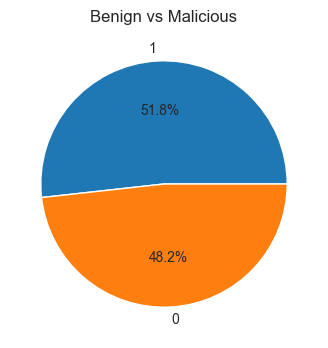

In [6]:
#Pie Chart
sns.set_style('whitegrid') 
plt.figure(figsize=(6, 4)) 
plt.pie(df['class'].value_counts(), labels=df['class'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')
plt.show()

In [7]:
# Feature Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Scaled Train Bounds: Min={x_train_scaled.min():.1f}, Max={x_train_scaled.max():.1f}")

Scaled Train Bounds: Min=0.0, Max=1.0


In [8]:
# 100 training, 30 testing
subset_train_size = 200
subset_test_size = 100

# randomized train and test
np.random.seed(42)
train_indices = np.random.choice(len(x_train_scaled), subset_train_size, replace=False)
test_indices = np.random.choice(len(x_test_scaled), subset_test_size, replace=False)

# Downsample scaled features
x_train_scaled_sub = x_train_scaled[train_indices]
x_test_scaled_sub = x_test_scaled[test_indices]

# Downsample labels
y_train_sub = y_train.iloc[train_indices]
y_test_sub = y_test.iloc[test_indices]

print(f"Downsampled Dimensions -> Train: {x_train_scaled_sub.shape}, Test: {x_test_scaled_sub.shape}")

Downsampled Dimensions -> Train: (200, 10), Test: (100, 10)


In [9]:
# Map the downsampled
qX_train = x_train_scaled_sub
qX_test = x_test_scaled_sub
qy_train = y_train_sub.values
qy_test = y_test_sub.values

print(f"Dataset Dimensions -> Train: {qX_train.shape}, Test: {qX_test.shape}")

# Aer Backend
backend = AerSimulator()

# creating the feature map
num_qubits = qX_train.shape[1]
raw_feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')
# Transpile for error avoidence for high level circuit
feature_map = transpile(raw_feature_map, backend)

#sampler and fidelity to handle the dataset
sampler = AerSampler.from_backend(backend)
fidelity = ComputeUncompute(sampler=sampler)

# Quantum Kernel
quantum_kernel = TrainableFidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

#decomposed feature map
feature_map.decompose().draw()

Dataset Dimensions -> Train: (200, 10), Test: (100, 10)


/Users/theaurilios/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


┌─────────┐┌─────────────────┐                                         »
q_0: ┤ U2(0,π) ├┤ U(0,0,2.0*x[0]) ├──■──────────────────────────────────────»
     ├─────────┤├─────────────────┤┌─┴─┐┌──────────────────────────────────┐»
q_1: ┤ U2(0,π) ├┤ U(0,0,2.0*x[1]) ├┤ X ├┤ U(0,0,2.0*(π - x[0])*(π - x[1])) ├»
     ├─────────┤├─────────────────┤└───┘└──────────────────────────────────┘»
q_2: ┤ U2(0,π) ├┤ U(0,0,2.0*x[2]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_3: ┤ U2(0,π) ├┤ U(0,0,2.0*x[3]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_4: ┤ U2(0,π) ├┤ U(0,0,2.0*x[4]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_5: ┤ U2(0,π) ├┤ U(0,0,2.0*x[5]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_6: ┤ U2(0,π) ├┤ U(0,0,2.0*x[6]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_7: ┤ U2(0,π) ├┤ U(0,0,2.0*x[7]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_8: ┤ U2(0,π) ├┤ U(0,0,2.0*x[8]) ├─────────────────────────────────────────»
     ├─────────┤├─────────────────┤                                         »
q_9: ┤ U2(0,π) ├┤ U(0,0,2.0*x[9]) ├─────────────────────────────────────────»
     └─────────┘└─────────────────┘                                         »
«          ┌─────────┐        ┌─────────────────┐                         »
«q_0: ──■──┤ U2(0,π) ├────────┤ U(0,0,2.0*x[0]) ├─────────────────────────»
«     ┌─┴─┐└─────────┘        └─────────────────┘              ┌─────────┐»
«q_1: ┤ X ├─────■───────────────────────────────────────────■──┤ U2(0,π) ├»
«     └───┘   ┌─┴─┐   ┌──────────────────────────────────┐┌─┴─┐└─────────┘»
«q_2: ────────┤ X ├───┤ U(0,0,2.0*(π - x[1])*(π - x[2])) ├┤ X ├─────■─────»
«             └───┘   └──────────────────────────────────┘└───┘   ┌─┴─┐   »
«q_3: ────────────────────────────────────────────────────────────┤ X ├───»
«                                                                 └───┘   »
«q_4: ────────────────────────────────────────────────────────────────────»
«                                                                         »
«q_5: ────────────────────────────────────────────────────────────────────»
«                                                                         »
«q_6: ────────────────────────────────────────────────────────────────────»
«                                                                         »
«q_7: ────────────────────────────────────────────────────────────────────»
«                                                                         »
«q_8: ────────────────────────────────────────────────────────────────────»
«                                                                         »
«q_9: ────────────────────────────────────────────────────────────────────»
«                                                                         »
«                                              »
«q_0: ──────────────────────────────────────■──»
«             ┌─────────────────┐         ┌─┴─┐»
«q_1: ────────┤ U(0,0,2.0*x[1]) ├─────────┤ X ├»
«             └─────────────────┘         └───┘»
«q_2: ──────────────────────────────────────■──»
«     ┌──────────────────────────────────┐┌─┴─┐»
«q_3: ┤ U(0,0,2.0*(π - x[2])*(π - x[3])) ├┤ X ├»
«     └──────────────────────────────────┘└───┘»
«q_4: ─────────────────────────────────────────»
«                                              »
«q_5: ─────────────────────────────────────────»
«                                              »
«q_6: ─────────────────────────────────────────»
«                                              »
«q_7: ──────────────────────────────

In [10]:
K_train = quantum_kernel.evaluate(qX_train, qX_train)

qsvm_model = SVC(kernel='precomputed', C=1.0, random_state=42)
qsvm_model.fit(K_train, qy_train)

K_test = quantum_kernel.evaluate(qX_test, qX_train)

# Predict the labels for the test data

y_pred = qsvm_model.predict(K_test)

# Calc accuracy and roc auc
acc = accuracy_score(qy_test, y_pred)
auc = roc_auc_score(qy_test, y_pred)

print(f"\nAccuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}\n")
print(classification_report(qy_test, y_pred, target_names=['Benign (0)', 'Malware (1)']))


Accuracy: 0.8600
ROC AUC:  0.8623

              precision    recall  f1-score   support

  Benign (0)       0.82      0.89      0.85        46
 Malware (1)       0.90      0.83      0.87        54

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100

